# Exploratory Data Analysis

In [42]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
# pd.reset_option("display.max_rows")
# pd.reset_option("display.max_columns")

## Import and Cleaning Data

In [67]:
# Exclude shootout shots (period = 5)
shot_df = pd.read_csv('nhl_shots_2019_2024.csv')
shot_df = shot_df[shot_df["period"] <= 4]
shot_df

,game_id,event_id,sort_order,period,period_type,time_in_period,time_remaining,situation_code,strength_state,away_goalie_pulled,home_goalie_pulled,shooting_team_strength_state,shooting_team_strength_diff,score_state,score_differential,shooter_id,goalie_id,team_id,shooter_team_abbrev,opponent_team_abbrev,is_home_team,event_type,x_coord_raw,y_coord_raw,x_coord,y_coord,zone,shot_type,is_goal,is_rebound,is_rush_shot,miss_reason
0,2019020001,10,11,1,REG,00:25,19:35,1551,5v5,False,False,5v5,0,NaN,NaN,8480801,8475883.0,9,OTT,TOR,False,goal,85.0,-1.0,85.0,-1.0,O,tip-in,1,NaN,NaN,NaN
1,2019020001,12,15,1,REG,00:38,19:22,1551,5v5,False,False,5v5,0,NaN,NaN,8479458,8475883.0,9,OTT,TOR,False,missed-shot,28.0,-37.0,28.0,-37.0,O,slap,0,NaN,NaN,wide-of-net
2,2019020001,15,28,1,REG,01:31,18:29,1451,4v5,False,False,5v4,1,NaN,NaN,8476853,8467950.0,10,TOR,OTT,True,shot-on-goal,-32.0,-2.0,32.0,-2.0,O,snap,0,NaN,NaN,NaN
3,2019020001,18,33,1,REG,01:58,18:02,1451,4v5,False,False,5v4,1,NaN,NaN,8478483,8467950.0,10,TOR,OTT,True,missed-shot,-46.0,-16.0,46.0,-16.0,O,wrist,0,NaN,NaN,wide-of-net
4,2019020001,19,44,1,REG,03:09,16:51,1551,5v5,False,False,5v5,0,NaN,NaN,8478857,8467950.0,10,TOR,OTT,True,missed-shot,-64.0,-4.0,64.0,-4.0,O,tip-in,0,NaN,NaN,wide-of-net
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622476,2024021312,1074,721,3,REG,17:54,02:06,1551,5v5,False,False,5v5,0,NaN,NaN,8475231,8482982.0,2,NYI,CBJ,False,shot-on-goal,-80.0,-4.0,80.0,-4.0,O,backhand,0,NaN,NaN,NaN
622477,2024021312,1078,727,3,REG,18:27,01:33,1551,5v5,False,False,5v5,0,NaN,NaN,8478460,8477405.0,29,CBJ,NYI,True,shot-on-goal,31.0,33.0,31.0,33.0,O,slap,0,NaN,NaN,NaN
622478,2024021312,1082,732,3,REG,18:37,01:23,1551,5v5,False,False,5v5,0,NaN,NaN,8484166,8477405.0,29,CBJ,NYI,True,goal,62.0,32.0,62.0,32.0,O,wrist,1,NaN,NaN,NaN
622479,2024021312,1086,736,3,REG,19:20,00:40,1551,5v5,False,False,5v5,0,NaN,NaN,8483485,8477405.0,29,CBJ,NYI,True,shot-on-goal,37.0,31.0,37.0,31.0,O,slap,0,NaN,NaN,NaN


### Missing Values

In [94]:
shot_df.isnull().sum()

game_id                              0
event_id                             0
sort_order                           0
period                               0
period_type                          0
time_in_period                       0
time_remaining                       0
situation_code                       0
strength_state                       0
away_goalie_pulled                   0
home_goalie_pulled                   0
shooting_team_strength_state         0
shooting_team_strength_diff          0
score_state                     618905
score_differential              618905
shooter_id                           0
goalie_id                         4147
team_id                              0
shooter_team_abbrev                  0
opponent_team_abbrev                 0
is_home_team                         0
event_type                           0
x_coord_raw                          0
y_coord_raw                          0
x_coord                              0
y_coord                  

miss_reason is null when shot_type is a shot on goal or a goal. Should replace null with an actual value like 'on net'. 

Features with all null valuesa are placeholders, like the parameters for 618905 null values.

The small number of null goalie_id and shot_type values should't be impactful.

### Shot Coordinates

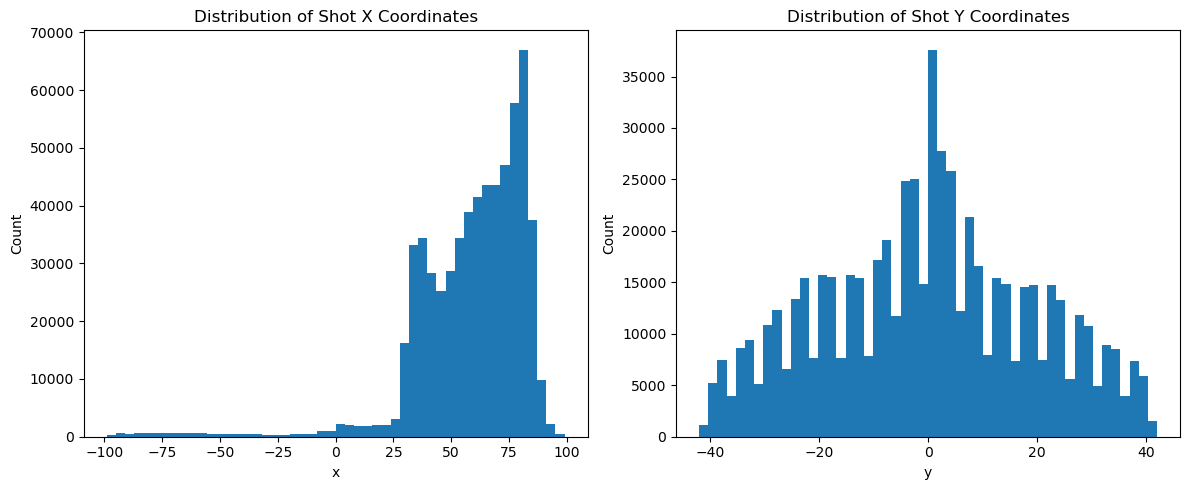

In [60]:
plt.figure(figsize=(12,5))

# Histogram of x-coordinates
plt.subplot(1, 2, 1)
plt.hist(shot_df["x_coord"], bins=50)
plt.title("Distribution of Shot X Coordinates")
plt.xlabel("x")
plt.ylabel("Count")

# Histogram of y-coordinates
plt.subplot(1, 2, 2)
plt.hist(shot_df["y_coord"], bins=50)
plt.title("Distribution of Shot Y Coordinates")
plt.xlabel("y")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

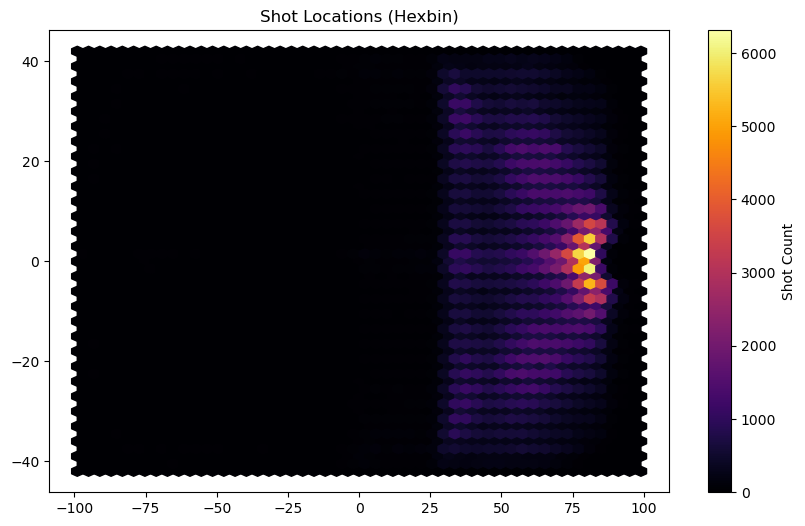

In [61]:
# Hexbin (hexagonal binning)
plt.figure(figsize=(10,6))
plt.hexbin(shot_df["x_coord"], shot_df["y_coord"], gridsize=50, cmap="inferno")
plt.colorbar(label="Shot Count")
plt.title("Shot Locations (Hexbin)")
plt.show()

Shot coordinate normalization to make shots all on one end worked correctly. Distribution of shots is as expected with most shots concentrated around the net.

In [62]:
# Checking how many shots result in goals
goal_pct = round(shot_df["is_goal"].value_counts(normalize=True)[1] * 100, 2)
print(f"{goal_pct}% of shots are goals.")

7.09% of shots are goals.


A 7.23% shooting percentage is in line with historical averages.

### Season Distributions

Creating season column and checking distribution of shots over seasons.

In [63]:
# Ensure game_id is string for slicing
shot_df['game_id_str'] = shot_df['game_id'].astype(str)
# Extract season start year from the first 4 digits of game_id
shot_df['season_start_year'] = shot_df['game_id_str'].str[:4].astype(int)
# Create a standard season label, e.g. "2019-20"
shot_df['season'] = shot_df['season_start_year'].apply(lambda x: f"{x}-{str(x+1)[-2:]}")
# Drop helper columns
shot_df.drop(columns=['game_id_str', 'season_start_year'], inplace=True)

In [64]:
# Shots in each season
display(shot_df["season"].value_counts())
# Shooting percentage from each season
shot_df.groupby("season")["is_goal"].mean()

season
2023-24    114839
2022-23    114088
2021-22    113290
2024-25    112237
2019-20     93140
2020-21     71311
Name: count, dtype: int64

season
2019-20    0.069229
2020-21    0.070550
2021-22    0.071939
2022-23    0.072295
2023-24    0.070412
2024-25    0.070396
Name: is_goal, dtype: float64

2019-20 and 2020-21 seasons have less shots due to shortened seasons (COVID). Shooting percentage is similar across all seasons.

### Shot and Event Types

In [65]:
# Distribution of shot types
display(shot_df["shot_type"].value_counts(dropna=False))
shot_df["shot_type"].value_counts(dropna=False, normalize=True)


shot_type
wrist           330923
snap             92583
slap             80890
tip-in           48327
backhand         44799
deflected        13576
wrap-around       5046
poke              1317
bat               1123
between-legs       219
NaN                 75
cradle              27
Name: count, dtype: int64

shot_type
wrist           0.534691
snap            0.149592
slap            0.130699
tip-in          0.078085
backhand        0.072384
deflected       0.021936
wrap-around     0.008153
poke            0.002128
bat             0.001814
between-legs    0.000354
NaN             0.000121
cradle          0.000044
Name: proportion, dtype: float64

Who knew there'd be 219 between the legs shots!! 

In [66]:
# Distribution of event types
display(shot_df["event_type"].value_counts(dropna=False))
shot_df["event_type"].value_counts(dropna=False, normalize=True)

event_type
shot-on-goal    394847
missed-shot     180194
goal             43864
Name: count, dtype: int64

event_type
shot-on-goal    0.637977
missed-shot     0.291150
goal            0.070874
Name: proportion, dtype: float64

### Strength States

In [73]:
# These two features show the same information but one is categorical, one is numerical
# Value counts of strength state - shooting team is first number
display(shot_df["shooting_team_strength_state"].value_counts(normalize=True))
shot_df["shooting_team_strength_diff"].value_counts(normalize=True)

shooting_team_strength_state
5v5    0.784529
5v4    0.133339
4v5    0.025201
6v5    0.018529
4v4    0.011095
3v3    0.010882
5v6    0.006048
5v3    0.004135
4v3    0.002538
6v4    0.002428
4v6    0.000431
1v0    0.000373
3v5    0.000263
3v4    0.000158
6v3    0.000042
3v6    0.000003
0v1    0.000003
Name: proportion, dtype: float64

shooting_team_strength_diff
 0    0.806507
 1    0.154780
-1    0.031410
 2    0.006563
-2    0.000695
 3    0.000042
-3    0.000003
Name: proportion, dtype: float64

### Time Features

Missing values:
time_in_period_sec    0
time_remaining_sec    0
dtype: int64

Consistency stats (sum of in_period + remaining):
count    618905.000000
mean       1188.069898
std         102.930957
min         300.000000
25%        1200.000000
50%        1200.000000
75%        1200.000000
max        1200.000000
Name: consistency_check, dtype: float64
Number of inconsistent rows: 0


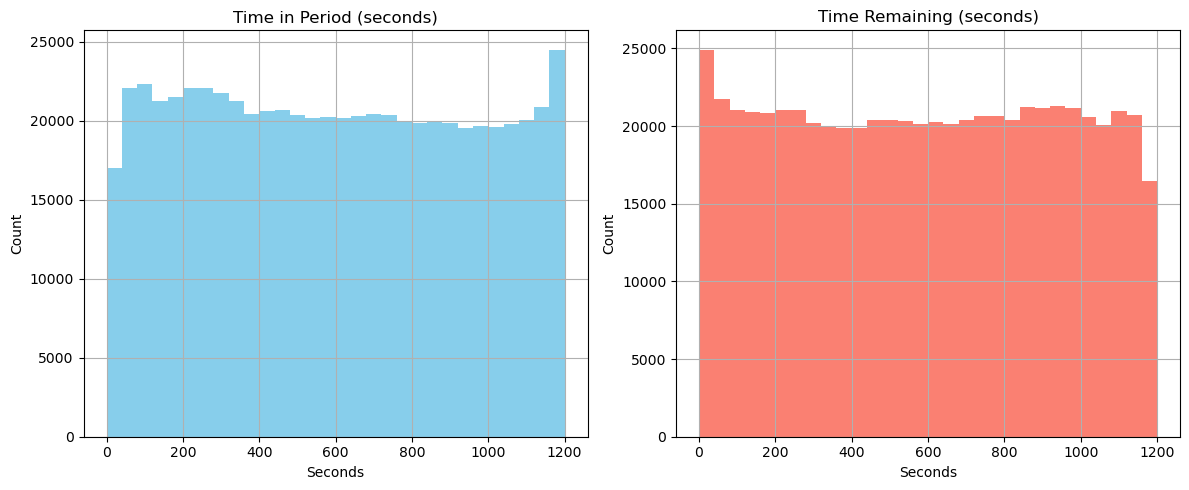

In [88]:
# Function to convet time to seconds
def time_to_seconds(t: str) -> float:
    """Convert MM:SS string to total seconds. Returns None if invalid."""
    try:
        minutes, seconds = map(int, t.split(":"))
        return minutes * 60 + seconds
    except:
        return None

# Convert columns
shot_df["time_in_period_sec"] = shot_df["time_in_period"].apply(time_to_seconds)
shot_df["time_remaining_sec"] = shot_df["time_remaining"].apply(time_to_seconds)

# Missing values
print("Missing values:")
print(shot_df[["time_in_period_sec", "time_remaining_sec"]].isna().sum())

# Define expected period lengths in seconds
period_lengths_sec = {
    "REG": 20 * 60,   # 20 minutes
    "OT": 5 * 60,     # 5 minutes for regular season OT
}

# Map the expected length to each row
shot_df["period_length_sec"] = shot_df["period_type"].map(period_lengths_sec)

# Check consistency
shot_df["consistency_check"] = shot_df["time_in_period_sec"] + shot_df["time_remaining_sec"]
print("\nConsistency stats (sum of in_period + remaining):")
print(shot_df["consistency_check"].describe())

# Flag inconsistencies
shot_df["inconsistent_time"] = abs(shot_df["consistency_check"] - shot_df["period_length_sec"]) > 0
print(f"Number of inconsistent rows: {shot_df['inconsistent_time'].sum()}")

# Plot distributions
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
shot_df["time_in_period_sec"].hist(bins=30, color="skyblue")
plt.title("Time in Period (seconds)")
plt.xlabel("Seconds")
plt.ylabel("Count")

plt.subplot(1,2,2)
shot_df["time_remaining_sec"].hist(bins=30, color="salmon")
plt.title("Time Remaining (seconds)")
plt.xlabel("Seconds")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Derived feature for modeling
# Fraction of period elapsed
shot_df["fraction_period_elapsed"] = shot_df["time_in_period_sec"] / shot_df["period_length_sec"]


Time features are 100% consisitent so that's good. There's a clear increase in shots near the end of each period and less at the beginning of each period.

These two features show the same thing, so I should remove one before modeling.

### Summary

Notes to do:
- For miss_reason, replace null values with actual value like 'on net' - ensure only for SOG or goal
- remove shots from shootouts (period = 5)
- combine away_goalie_pulled and home_goalie_pulled into empty_net_shot feature

Redunduant features to drop before modeling:
- x_coord_raw, y_coord_raw
- strength_state, situation_code
- away_goalie_pulled, home_goalie_pulled (once new empty_net_shot feature is made)
- time_remaining

Additional features to add:
- empty_net_shot
- time_since_last_shot (using time_into_period)
- distance and angle to net? Or are those accounted for in coordinates?
